# HiCRep Analysis: Input, CNN, and HiCFoundation Decoder Variants

Compare HiCRep stratum-adjusted correlation coefficient (SCC) across all models.

In [1]:
import os
import sys

sys.path.insert(0, os.path.join("..", "..", "src"))

import numpy as np
import torch
from tqdm import tqdm

from hic_dataset import SubmatrixDataset
from hic_model import SimpleEnhanceCNN, HiCFoundationHead
from hic_train import (
    compute_hicrep,
    compute_hicrep_scores,
    load_or_compute_scores,
    plot_ssim_violin_5way,
    plot_score_scatter,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

test_dataset = SubmatrixDataset(os.path.join("..", "..", "results", "submatrices", "frac_0.05", "test.h5"))
print(f"Test dataset size: {len(test_dataset)}")

cache_dir = os.path.join("..", "..", "results", "score_cache")

Using device: cuda
Test dataset size: 5026


In [2]:
# Compute HiCRep for input vs target (baseline)
def compute_input_hicrep(dataset):
    scores = []
    for idx in tqdm(range(len(dataset)), desc="Input HiCRep", total=len(dataset)):
        x, y = dataset[idx]
        x_np = np.clip(x[0].numpy(), 0, None)
        y_np = np.clip(y[0].numpy(), 0, None)
        scores.append(compute_hicrep(x_np, y_np))
    return np.array(scores)

input_hicrep = load_or_compute_scores(
    os.path.join(cache_dir, "hicrep_input.npz"),
    compute_input_hicrep, test_dataset
)
print(f"Input HiCRep: mean={input_hicrep.mean():.4f}, std={input_hicrep.std():.4f}")

Loading cached scores from ..\results\score_cache\hicrep_input.npz
Input HiCRep: mean=0.6144, std=0.0695


In [3]:
# Load CNN model and compute HiCRep
cnn_run_date = "2026-07-30"
cnn_model_path = os.path.join("..", "..", "results", "training", cnn_run_date, "model.pt")

cnn_model = SimpleEnhanceCNN()
cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn_model.to(device).eval()

cnn_hicrep = load_or_compute_scores(
    os.path.join(cache_dir, "hicrep_cnn.npz"),
    compute_hicrep_scores, cnn_model, test_dataset, device
)
print(f"CNN HiCRep: mean={cnn_hicrep.mean():.4f}, std={cnn_hicrep.std():.4f}")

Loading cached scores from ..\results\score_cache\hicrep_cnn.npz
CNN HiCRep: mean=0.6906, std=0.0792


C:\Users\momoh\AppData\Local\Temp\ipykernel_64004\389738371.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(cnn_model_path, map_loca

In [4]:
# Load HiCFoundation models (1, 4, 8 layer)
hicf_run_date = "2026-08-11"
hicf_weights = os.path.join("..", "..", "hicfoundation_model", "hicfoundation_pretrain.pth.tar")

hicf_hicrep = {}

for layers in [1, 4, 8]:
    model_path = os.path.join("..", "..", "results", f"training_hicfoundation_{layers}layer", hicf_run_date, "model.pt")

    model = HiCFoundationHead(hicf_weights, decoder_layers=layers)
    state_dict = torch.load(model_path, map_location=device)

    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=False)
    model.to(device).eval()

    hicf_hicrep[layers] = load_or_compute_scores(
        os.path.join(cache_dir, f"hicrep_hicf_{layers}layer.npz"),
        compute_hicrep_scores, model, test_dataset, device
    )
    print(f"HiCFoundation {layers}-layer: mean={hicf_hicrep[layers].mean():.4f}, std={hicf_hicrep[layers].std():.4f}")

print("\nAll models scored")

C:\Users\momoh\AppData\Local\Temp\ipykernel_64004\269524207.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Loading cached scores from ..\results\score_cache\hicrep_hicf_1layer.npz
HiCFoundation 1-layer: mean=0.7495, std=0.0831
Loading cached scores from ..\results\score_cache\hicrep_hicf_4layer.npz
HiCFoundation 4-layer: mean=0.7535, std=0.0815
Loading cached scores from ..\results\score_cache\hicrep_hicf_8layer.npz
HiCFoundation 8-layer: mean=0.7541, std=0.0810

All models scored


In [5]:
# Compile all scores for comparison
all_scores = {
    "Input": input_hicrep,
    "CNN": cnn_hicrep,
    "HiCFoundation (1-layer)": hicf_hicrep[1],
    "HiCFoundation (4-layer)": hicf_hicrep[4],
    "HiCFoundation (8-layer)": hicf_hicrep[8],
}

print("\n" + "="*60)
print("HiCRep Summary Statistics (mean ± std)")
print("="*60)
for label, scores in all_scores.items():
    print(f"{label:30s}: {scores.mean():.4f} ± {scores.std():.4f}")
print("="*60)


HiCRep Summary Statistics (mean ± std)
Input                         : 0.6144 ± 0.0695
CNN                           : 0.6906 ± 0.0792
HiCFoundation (1-layer)       : 0.7495 ± 0.0831
HiCFoundation (4-layer)       : 0.7535 ± 0.0815
HiCFoundation (8-layer)       : 0.7541 ± 0.0810


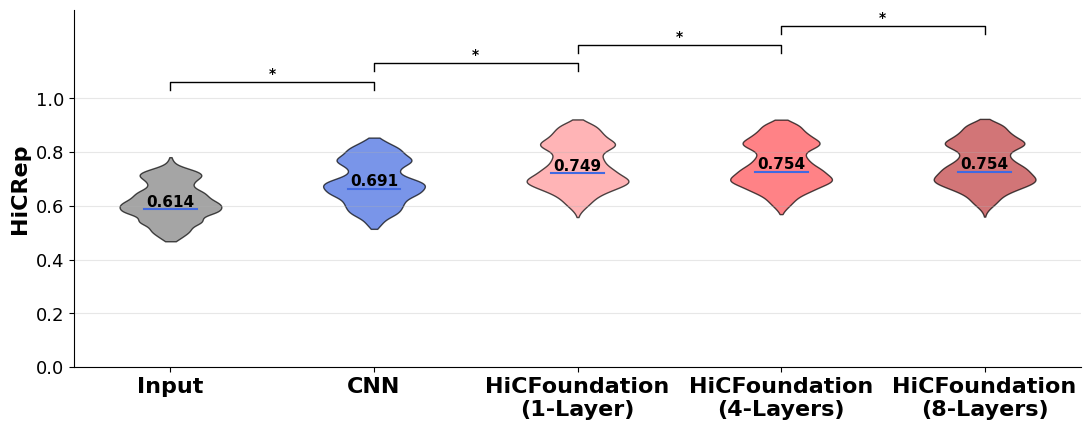

Violin plot saved


In [6]:
# Create violin plot comparing all models
comparison_dir = os.path.join("..", "..", "results", "plots", "hicrep_analysis")
os.makedirs(comparison_dir, exist_ok=True)

plot_ssim_violin_5way(
    all_scores,
    metric_name="HiCRep",
    save_path=os.path.join(comparison_dir, "violin_plot_all_models.png"),
    pairs=[
        ("Input", "CNN"),
        ("CNN", "HiCFoundation (1-layer)"),
        ("HiCFoundation (1-layer)", "HiCFoundation (4-layer)"),
        ("HiCFoundation (4-layer)", "HiCFoundation (8-layer)")
    ]
)
print("Violin plot saved")

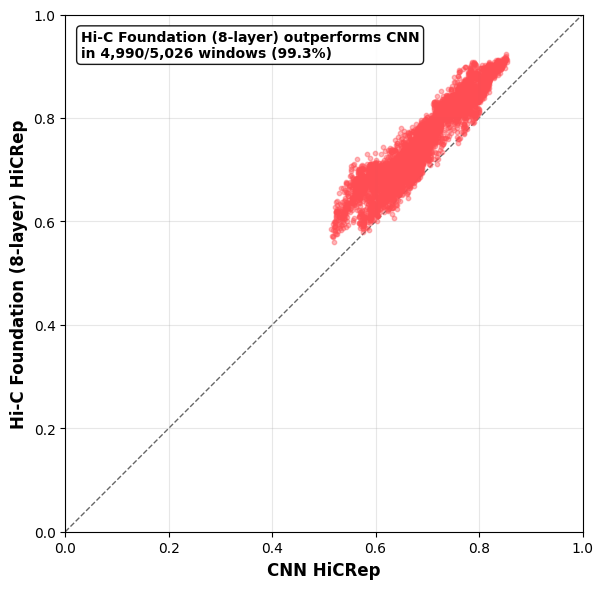

Scatter plot (CNN vs 8-layer) saved


In [7]:
best_hicf = hicf_hicrep[8]

plot_score_scatter(
    cnn_hicrep, best_hicf,
    label_x="CNN", label_y="Hi-C Foundation (8-layer)",
    metric_name="HiCRep",
    save_path=os.path.join(comparison_dir, "scatter_cnn_vs_hicf_8layer.png")
)
print("Scatter plot (CNN vs 8-layer) saved")

In [8]:
print("\n" + "="*60)
print("Best Model Comparison: CNN vs HiCFoundation (8-layer)")
print("="*60)
print(f"CNN:                  mean={cnn_hicrep.mean():.4f} ± {cnn_hicrep.std():.4f}")
print(f"HiCF (8-layer):       mean={best_hicf.mean():.4f} ± {best_hicf.std():.4f}")
print(f"Difference (HiCF - CNN): {(best_hicf.mean() - cnn_hicrep.mean()):.4f}")

better_count = (best_hicf > cnn_hicrep).sum()
pct_better = 100 * better_count / len(best_hicf)
print(f"Windows where HiCF > CNN: {better_count}/{len(best_hicf)} ({pct_better:.1f}%)")
print("="*60)

test_dataset.close()


Best Model Comparison: CNN vs HiCFoundation (8-layer)
CNN:                  mean=0.6906 ± 0.0792
HiCF (8-layer):       mean=0.7541 ± 0.0810
Difference (HiCF - CNN): 0.0635
Windows where HiCF > CNN: 4990/5026 (99.3%)
